# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Model Choice

[Explain why you've chosen a particular model as the baseline. This could be a simple statistical model or a basic machine learning model. Justify your choice.]


Simple Neural Network with Linear Layers and ReLu. Close to a potential final classification layer in a future model.

## Feature Selection

[Indicate which features from the dataset you will be using for the baseline model, and justify your selection.]


Different numerical features (aggregates) representating the data, such as the total value of the shopping basked, the number of items, the maximum price of an item in the basket and the average price. We also add the number of occurences of an item from the "Computer" category as many fraudulent baskets have items of that category (as seen in the exploratory data analysis)

In [3]:
# Load the dataset
x_df = pd.read_csv('../data/X_train.csv')
y_df = pd.read_csv('../data/Y_train.csv')

C:\Users\tomhi\AppData\Local\Temp\ipykernel_23584\4008261101.py:2: DtypeWarning: Columns (0: item21, 1: item22, 2: item23, 3: item24, 4: make21, 5: make22, 6: make23, 7: make24, 8: model21, 9: model22, 10: model23, 11: model24, 12: goods_code1, 13: goods_code8, 14: goods_code9, 15: goods_code10, 16: goods_code11, 17: goods_code12, 18: goods_code13, 19: goods_code14, 20: goods_code15, 21: goods_code16, 22: goods_code17, 23: goods_code18, 24: goods_code19, 25: goods_code20, 26: goods_code21, 27: goods_code22, 28: goods_code23, 29: goods_code24) have mixed types. Specify dtype option on import or set low_memory=False.
  x_df = pd.read_csv('../data/X_train.csv')


In [4]:
# Add aggregate features 
price_cols = [f'cash_price{i}' for i in range(1, 25)]
prod_purchas_col = [f'Nbr_of_prod_purchas{i}' for i in range(1, 25)]

x_df['total_basket_value'] = x_df[price_cols].sum(axis=1, skipna=True)
x_df['num_of_items'] = x_df[prod_purchas_col].sum(axis=1, skipna=True)
x_df['max_item_price'] = x_df[price_cols].max(axis=1, skipna=True)
x_df['avg_item_price'] = x_df['total_basket_value'] / x_df['num_of_items']

item_cols = [f'item{i}' for i in range(1, 25)]
x_df['computer_count'] = (x_df[item_cols] == 'COMPUTERS').sum(axis=1) / x_df['num_of_items'] # computers are the most common fraud item



feature_columns = ['num_of_items', 'total_basket_value', 'max_item_price', 'avg_item_price', 'computer_count']
num_features = x_df[feature_columns].copy()

num_features.head()

,num_of_items,total_basket_value,max_item_price,avg_item_price,computer_count
0,1.0,889.0,889.0,889.0,1.0
1,1.0,409.0,409.0,409.0,0.0
2,1.0,1399.0,1399.0,1399.0,0.0
3,2.0,808.0,689.0,404.0,0.5
4,1.0,1199.0,1199.0,1199.0,0.0


In [5]:
from sklearn.preprocessing import StandardScaler

x_data = torch.tensor(num_features.values, dtype=torch.float32)

y_fraud_flag = y_df[['fraud_flag']].copy()
y_data = torch.tensor(y_fraud_flag.values, dtype=torch.float32)

print(x_data.shape)
print(y_data.shape)

torch.Size([92790, 5])
torch.Size([92790, 1])


In [6]:
# Split data in training, validation and test set - 60% train, 20% val, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(x_data, y_data, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Dataset/Dataloader

In [7]:
from torch.utils.data import Dataset

class FraudDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.y[idx]
        )

In [8]:
scaler = StandardScaler()

def preprocess(x, fit=False):
    global scaler

    if fit:
        x_scaled = scaler.fit_transform(x)
    else:
        x_scaled = scaler.transform(x)

    return torch.tensor(x_scaled, dtype=torch.float32)

# Preprocess data
X_train = preprocess(X_train, fit=True)
X_val = preprocess(X_val)
X_test = preprocess(X_test)

In [9]:
# DataSet
train_dataset = FraudDataset(X_train, y_train)
val_dataset = FraudDataset(X_val, y_val)
test_dataset = FraudDataset(X_test, y_test)

In [10]:
# Data Loaders
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Implementation

[Implement your baseline model here.]



In [11]:
# Initialize the baseline model
N_INPUT_FEATURES = len(feature_columns)
LEARNING_RATE = 0.0001
NUM_EPOCHS = 100
DROPOUT_RATE = 0.2

model = nn.Sequential(
    nn.Linear(N_INPUT_FEATURES, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Dropout(DROPOUT_RATE),
    nn.Linear(8, 1),
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_function = nn.BCEWithLogitsLoss()

print(model)


Sequential(
  (0): Linear(in_features=5, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.2, inplace=False)
  (5): Linear(in_features=8, out_features=1, bias=True)
)


In [12]:
# Train and validate the baseline model
from sklearn.metrics import average_precision_score

train_losses = []
val_losses = []
pr_aucs = []

for epoch in range(NUM_EPOCHS):
    # --- TRAINING ---
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = loss_function(outputs, batch_y.float().squeeze())
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X).squeeze()
            loss = loss_function(outputs, batch_y.float().squeeze())
            val_loss += loss.item() * batch_X.size(0)

            # convert logits to probabilities
            probs = torch.sigmoid(outputs)
            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    pr_auc = average_precision_score(all_labels, all_preds)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    pr_aucs.append(pr_auc)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {avg_val_loss:.4f} | '
          f'VAL PR-AUC: {pr_auc:.4f}')

Epoch 1/100 | Train Loss: 0.6435 | Val Loss: 0.4482 | VAL PR-AUC: 0.0115
Epoch 2/100 | Train Loss: 0.2970 | Val Loss: 0.1695 | VAL PR-AUC: 0.0176
Epoch 3/100 | Train Loss: 0.1391 | Val Loss: 0.0927 | VAL PR-AUC: 0.0246
Epoch 4/100 | Train Loss: 0.0976 | Val Loss: 0.0765 | VAL PR-AUC: 0.0286
Epoch 5/100 | Train Loss: 0.0890 | Val Loss: 0.0733 | VAL PR-AUC: 0.0353
Epoch 6/100 | Train Loss: 0.0847 | Val Loss: 0.0726 | VAL PR-AUC: 0.0417
Epoch 7/100 | Train Loss: 0.0844 | Val Loss: 0.0722 | VAL PR-AUC: 0.0449
Epoch 8/100 | Train Loss: 0.0826 | Val Loss: 0.0719 | VAL PR-AUC: 0.0479
Epoch 9/100 | Train Loss: 0.0822 | Val Loss: 0.0717 | VAL PR-AUC: 0.0524
Epoch 10/100 | Train Loss: 0.0807 | Val Loss: 0.0716 | VAL PR-AUC: 0.0532
Epoch 11/100 | Train Loss: 0.0806 | Val Loss: 0.0713 | VAL PR-AUC: 0.0456
Epoch 12/100 | Train Loss: 0.0798 | Val Loss: 0.0712 | VAL PR-AUC: 0.0445
Epoch 13/100 | Train Loss: 0.0798 | Val Loss: 0.0712 | VAL PR-AUC: 0.0444
Epoch 14/100 | Train Loss: 0.0789 | Val Loss: 0

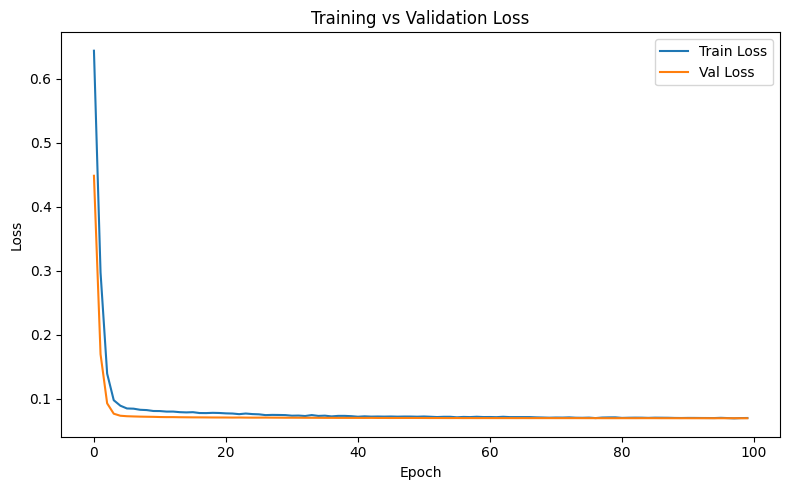

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

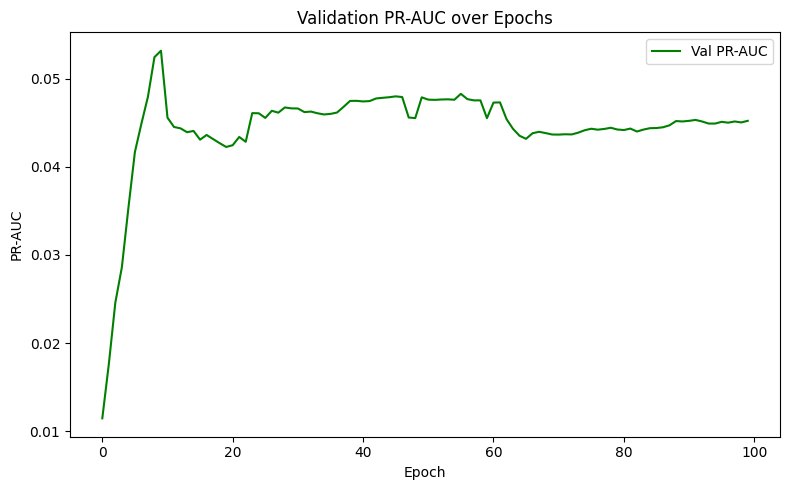

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(pr_aucs, label='Val PR-AUC', color='green')
plt.xlabel('Epoch')
plt.ylabel('PR-AUC')
plt.title('Validation PR-AUC over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation

[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]



**Metric:** PR-AUC as defined in the project's description - supposed to capture how well the model handles the class imbalance


In [15]:
# Evaluate the baseline model on test set

model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X).squeeze()
        probs = torch.sigmoid(outputs)
        test_preds.extend(probs.cpu().numpy())
        test_labels.extend(batch_y.cpu().numpy())

test_pr_auc = average_precision_score(test_labels, test_preds)
print(f'++ Test Set PR-AUC: {test_pr_auc:.4f} ++')


++ Test Set PR-AUC: 0.0580 ++


## Cross Validation

In [16]:
from sklearn.model_selection import KFold

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# hold out permanent test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    num_features.values, y_df[['fraud_flag']].values, test_size=0.2, random_state=42
)

# scale test set (fit only on trainval)
scaler_final = StandardScaler()
scaler_final.fit(X_trainval)
X_test_tensor = torch.tensor(scaler_final.transform(X_test), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
test_loader = DataLoader(FraudDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

fold_pr_aucs = []
best_pr_auc = 0
best_model = None

RUN_CROSS_VAL = True

if not RUN_CROSS_VAL:
    print("Cross-validation skipped. Set RUN_CROSS_VAL = True to run it.")
else:
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
        print(f'\n--- Fold {fold+1}/{N_SPLITS} ---')

        X_train_fold, X_val_fold = X_trainval[train_idx], X_trainval[val_idx]
        y_train_fold, y_val_fold = y_trainval[train_idx], y_trainval[val_idx]

        scaler = StandardScaler()
        X_train_fold = torch.tensor(scaler.fit_transform(X_train_fold), dtype=torch.float32).to(device)
        X_val_fold = torch.tensor(scaler.transform(X_val_fold), dtype=torch.float32).to(device)
        y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32).to(device)
        y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32).to(device)

        train_loader = DataLoader(FraudDataset(X_train_fold, y_train_fold), batch_size=64, shuffle=True)
        val_loader = DataLoader(FraudDataset(X_val_fold, y_val_fold), batch_size=64, shuffle=False)

        model = nn.Sequential(
            nn.Linear(N_INPUT_FEATURES, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(8, 1),
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
        loss_function = nn.BCEWithLogitsLoss()

        for epoch in range(NUM_EPOCHS):
            model.train()
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                loss = loss_function(model(batch_X).squeeze(), batch_y.float().squeeze())
                loss.backward()
                optimizer.step()

        # validate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                probs = torch.sigmoid(model(batch_X).squeeze())
                all_preds.extend(probs.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())

        pr_auc = average_precision_score(all_labels, all_preds)
        fold_pr_aucs.append(pr_auc)
        print(f'Fold {fold+1} Val PR-AUC: {pr_auc:.4f}')

        # save best model
        if pr_auc > best_pr_auc:
            best_pr_auc = pr_auc
            best_model = model
            torch.save(best_model.state_dict(), "best_baseline_model.pt")
            print(f'  -> New best model (PR-AUC: {best_pr_auc:.4f})')

    print(f'\nMean Val PR-AUC: {np.mean(fold_pr_aucs):.4f} (+/- {np.std(fold_pr_aucs):.4f})')

    # --- FINAL EVALUATION ON HELD OUT TEST SET ---
    best_model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            probs = torch.sigmoid(best_model(batch_X).squeeze())
            test_preds.extend(probs.cpu().numpy())
            test_labels.extend(batch_y.cpu().numpy())

    test_pr_auc = average_precision_score(test_labels, test_preds)
    print(f'\n++ Test Set PR-AUC (best model): {test_pr_auc:.4f} ++')


--- Fold 1/5 ---
Fold 1 Val PR-AUC: 0.0464
  -> New best model (PR-AUC: 0.0464)

--- Fold 2/5 ---
Fold 2 Val PR-AUC: 0.0418

--- Fold 3/5 ---
Fold 3 Val PR-AUC: 0.0595
  -> New best model (PR-AUC: 0.0595)

--- Fold 4/5 ---
Fold 4 Val PR-AUC: 0.0571

--- Fold 5/5 ---
Fold 5 Val PR-AUC: 0.0669
  -> New best model (PR-AUC: 0.0669)

Mean Val PR-AUC: 0.0543 (+/- 0.0091)

++ Test Set PR-AUC (best model): 0.0510 ++


## Create submission file

In [19]:
test_df = pd.read_csv('../data/X_test.csv')

test_df['total_basket_value'] = test_df[price_cols].sum(axis=1, skipna=True)
test_df['num_of_items'] = test_df[prod_purchas_col].sum(axis=1, skipna=True)
test_df['max_item_price'] = test_df[price_cols].max(axis=1, skipna=True)
test_df['avg_item_price'] = test_df['total_basket_value'] / test_df['num_of_items']

item_cols = [f'item{i}' for i in range(1, 25)]
test_df['computer_count'] = (test_df[item_cols] == 'COMPUTERS').sum(axis=1) / test_df['num_of_items'] # computers are the most common fraud item


feature_columns = ['num_of_items', 'total_basket_value', 'max_item_price', 'avg_item_price', 'computer_count']
X_test_features  = test_df[feature_columns].copy()

C:\Users\tomhi\AppData\Local\Temp\ipykernel_23584\2302335454.py:1: DtypeWarning: Columns (0: item20, 1: item21, 2: item22, 3: item23, 4: item24, 5: make20, 6: make21, 7: make22, 8: make23, 9: make24, 10: model20, 11: model21, 12: model22, 13: model23, 14: model24, 15: goods_code1, 16: goods_code10, 17: goods_code11, 18: goods_code12, 19: goods_code13, 20: goods_code14, 21: goods_code15, 22: goods_code16, 23: goods_code17, 24: goods_code18, 25: goods_code19, 26: goods_code20, 27: goods_code21, 28: goods_code22) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('../data/X_test.csv')


In [20]:
best_model.load_state_dict(torch.load("best_baseline_model.pt"))
X_test_scaled = scaler_final.transform(X_test_features)

# Convert to tensor
X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

# Create test dataset + loader
test_dataset = torch.utils.data.TensorDataset(X_test_tensor)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Predict with best model
best_model.eval()

test_probs = []

with torch.no_grad():

    for (batch_X,) in test_loader:
        batch_X = batch_X.to(device)
        logits = best_model(batch_X).squeeze()
        probs = torch.sigmoid(logits)

        test_probs.extend(probs.cpu().numpy().flatten())

# Create submission file
submission = pd.DataFrame({
    "index": range(len(test_df)),
    "ID": test_df["ID"],
    "fraud_flag": test_probs
})

submission.to_csv("baseline_submission.csv", index=False)

print(submission.head())
print("\nbaseline_submission.csv saved!")

c:\Users\tomhi\miniconda3\envs\advml\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


   index     ID  fraud_flag
0      0  64707    0.001567
1      1  63919    0.001338
2      2  15664    0.012781
3      3   6626    0.008331
4      4  26766    0.045406

baseline_submission.csv saved!
